In [1]:
"""
Evasion Attacks on CIFAR-10: FGSM and Projected Gradient Descent (PGD)
=======================================================================
This script demonstrates two classic white-box evasion attacks:
  1. Fast Gradient Sign Method (FGSM)  – Goodfellow et al., 2014
  2. Projected Gradient Descent (PGD)  – Madry et al., 2018

Both attacks craft adversarial examples by adding small, carefully
computed perturbations to input images so that the model misclassifies them,
while the perturbation remains imperceptible (bounded by epsilon).
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# ── Device ────────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

CIFAR10_CLASSES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]


# ── Model ─────────────────────────────────────────────────────────────────────
class SimpleCNN(nn.Module):
    """A small CNN sufficient to demonstrate adversarial attacks."""

    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),                          # 16×16

            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),                          # 8×8
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256), nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


# ── Data ──────────────────────────────────────────────────────────────────────
def get_loaders(batch_size: int = 128):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465),
                              (0.2023, 0.1994, 0.2010)),
    ])
    train_set = torchvision.datasets.CIFAR10(
        root="./data", train=True, download=True, transform=transform)
    test_set = torchvision.datasets.CIFAR10(
        root="./data", train=False, download=True, transform=transform)
    train_loader = torch.utils.data.DataLoader(
        train_set, batch_size=batch_size, shuffle=True, num_workers=2)
    test_loader = torch.utils.data.DataLoader(
        test_set, batch_size=batch_size, shuffle=False, num_workers=2)
    return train_loader, test_loader


# ── Training ──────────────────────────────────────────────────────────────────
def train(model, loader, optimizer, criterion, epochs: int = 10):
    model.train()
    for epoch in range(epochs):
        total_loss, correct, total = 0.0, 0, 0
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
        print(f"Epoch {epoch+1}/{epochs}  "
              f"Loss: {total_loss/len(loader):.3f}  "
              f"Acc: {100*correct/total:.1f}%")


def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            correct += (model(images).argmax(1) == labels).sum().item()
            total += labels.size(0)
    return 100 * correct / total

Using device: cpu


In [2]:
# ══════════════════════════════════════════════════════════════════════════════
#  ATTACK 1 – Fast Gradient Sign Method (FGSM)
# ══════════════════════════════════════════════════════════════════════════════
def fgsm_attack(model, images, labels, epsilon: float):
    """
    FGSM: perturb each pixel by epsilon in the direction that *maximises* loss.

        x_adv = x + epsilon * sign( ∇_x L(model(x), y) )

    Parameters
    ----------
    model   : trained classifier
    images  : clean batch, shape (N, C, H, W), requires_grad will be set
    labels  : true labels, shape (N,)
    epsilon : max perturbation magnitude (in normalised pixel space)

    Returns
    -------
    adv_images : adversarial examples clipped to [0, 1] in normalised space
    """
    images = images.clone().detach().to(device)
    labels = labels.clone().detach().to(device)
    images.requires_grad_(True)

    outputs = model(images)
    loss = F.cross_entropy(outputs, labels)
    model.zero_grad()
    loss.backward()

    # Take one step in the gradient-sign direction
    perturbation = epsilon * images.grad.sign()
    adv_images = images + perturbation

    # Clip so the image stays in a valid normalised range
    # CIFAR-10 pixels after normalisation roughly lie in [-2, 2]
    adv_images = torch.clamp(adv_images, -2.5, 2.5)
    return adv_images.detach()


# ══════════════════════════════════════════════════════════════════════════════
#  ATTACK 2 – Projected Gradient Descent (PGD)
# ══════════════════════════════════════════════════════════════════════════════
def pgd_attack(model, images, labels,
               epsilon: float,
               alpha: float,
               num_steps: int,
               random_start: bool = True):
    """
    PGD: iterative FGSM with projection back into the epsilon-ball.

    At each step:
        x_{t+1} = Proj_{B(x, ε)} ( x_t + α * sign(∇_x L) )

    Where Proj clips the perturbation so it never exceeds epsilon.

    Parameters
    ----------
    model        : trained classifier
    images       : clean batch (N, C, H, W)
    labels       : true labels (N,)
    epsilon      : radius of the L∞ threat model
    alpha        : step size per iteration
    num_steps    : number of PGD iterations
    random_start : initialise inside the epsilon-ball randomly (recommended)

    Returns
    -------
    adv_images : adversarial examples
    """
    images = images.clone().detach().to(device)
    labels = labels.clone().detach().to(device)

    if random_start:
        # Start from a random point inside the epsilon-ball
        delta = torch.empty_like(images).uniform_(-epsilon, epsilon)
        adv_images = torch.clamp(images + delta, -2.5, 2.5).detach()
    else:
        adv_images = images.clone()

    for _ in range(num_steps):
        adv_images.requires_grad_(True)

        outputs = model(adv_images)
        loss = F.cross_entropy(outputs, labels)
        model.zero_grad()
        loss.backward()

        # Gradient-sign step
        adv_images = adv_images + alpha * adv_images.grad.sign()

        # Project back into the L∞ epsilon-ball around the original image
        perturbation = torch.clamp(adv_images - images, -epsilon, epsilon)
        adv_images = torch.clamp(images + perturbation, -2.5, 2.5).detach()

    return adv_images

In [3]:
# ── Evaluation under attack ───────────────────────────────────────────────────
def evaluate_under_attack(model, loader, attack_fn, attack_kwargs,
                           num_batches: int = 10):
    """
    Run the given attack on `num_batches` mini-batches and report accuracy.
    """
    model.eval()
    correct, total = 0, 0
    for i, (images, labels) in enumerate(loader):
        if i >= num_batches:
            break
        images, labels = images.to(device), labels.to(device)
        adv_images = attack_fn(model, images, labels, **attack_kwargs)
        with torch.no_grad():
            preds = model(adv_images).argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return 100 * correct / total


# ── Visualisation ─────────────────────────────────────────────────────────────
def denormalise(tensor):
    """Reverse CIFAR-10 normalisation for display."""
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    std  = torch.tensor([0.2023, 0.1994, 0.2010]).view(3, 1, 1)
    return (tensor.cpu() * std + mean).clamp(0, 1)


def visualise_attacks(model, images, labels, epsilon, alpha, pgd_steps,
                      n: int = 5):
    """
    Display n original / FGSM / PGD image triples with predicted labels.
    """
    model.eval()
    imgs   = images[:n].to(device)
    lbls   = labels[:n].to(device)

    fgsm_imgs = fgsm_attack(model, imgs, lbls, epsilon)
    pgd_imgs  = pgd_attack(model, imgs, lbls, epsilon, alpha, pgd_steps)

    fig, axes = plt.subplots(3, n, figsize=(3 * n, 9))
    row_titles = ["Original", f"FGSM (ε={epsilon})",
                  f"PGD (ε={epsilon}, steps={pgd_steps})"]

    for row, (title, batch) in enumerate(
            zip(row_titles, [imgs, fgsm_imgs, pgd_imgs])):
        with torch.no_grad():
            preds = model(batch).argmax(1)
        for col in range(n):
            ax = axes[row, col]
            img_np = denormalise(batch[col]).permute(1, 2, 0).numpy()
            ax.imshow(img_np)
            ax.axis("off")
            true_cls = CIFAR10_CLASSES[lbls[col].item()]
            pred_cls = CIFAR10_CLASSES[preds[col].item()]
            colour = "green" if true_cls == pred_cls else "red"
            ax.set_title(f"T: {true_cls}\nP: {pred_cls}",
                         fontsize=8, color=colour)
        axes[row, 0].set_ylabel(title, fontsize=10, rotation=90,
                                labelpad=5, va="center")

    plt.suptitle("Evasion Attacks on CIFAR-10", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig("attack_visualisation.png", dpi=150)
    plt.show()
    print("Saved: attack_visualisation.png")


Files already downloaded and verified
Files already downloaded and verified

=== Training ===
Epoch 1/10  Loss: 1.450  Acc: 47.5%
Epoch 2/10  Loss: 0.997  Acc: 64.9%
Epoch 3/10  Loss: 0.793  Acc: 72.2%
Epoch 4/10  Loss: 0.675  Acc: 76.4%
Epoch 5/10  Loss: 0.581  Acc: 79.7%
Epoch 6/10  Loss: 0.502  Acc: 82.3%
Epoch 7/10  Loss: 0.426  Acc: 84.9%
Epoch 8/10  Loss: 0.374  Acc: 86.7%
Epoch 9/10  Loss: 0.323  Acc: 88.2%
Epoch 10/10  Loss: 0.284  Acc: 89.9%

Clean test accuracy: 79.2%

=== Evaluating under FGSM ===
FGSM accuracy (ε=0.03): 39.3%

=== Evaluating under PGD ===
PGD accuracy  (ε=0.03, steps=20): 26.9%

Attack                      Accuracy
---------------------------------------------
Clean (no attack)              79.2%
FGSM                           39.3%
PGD                            26.9%


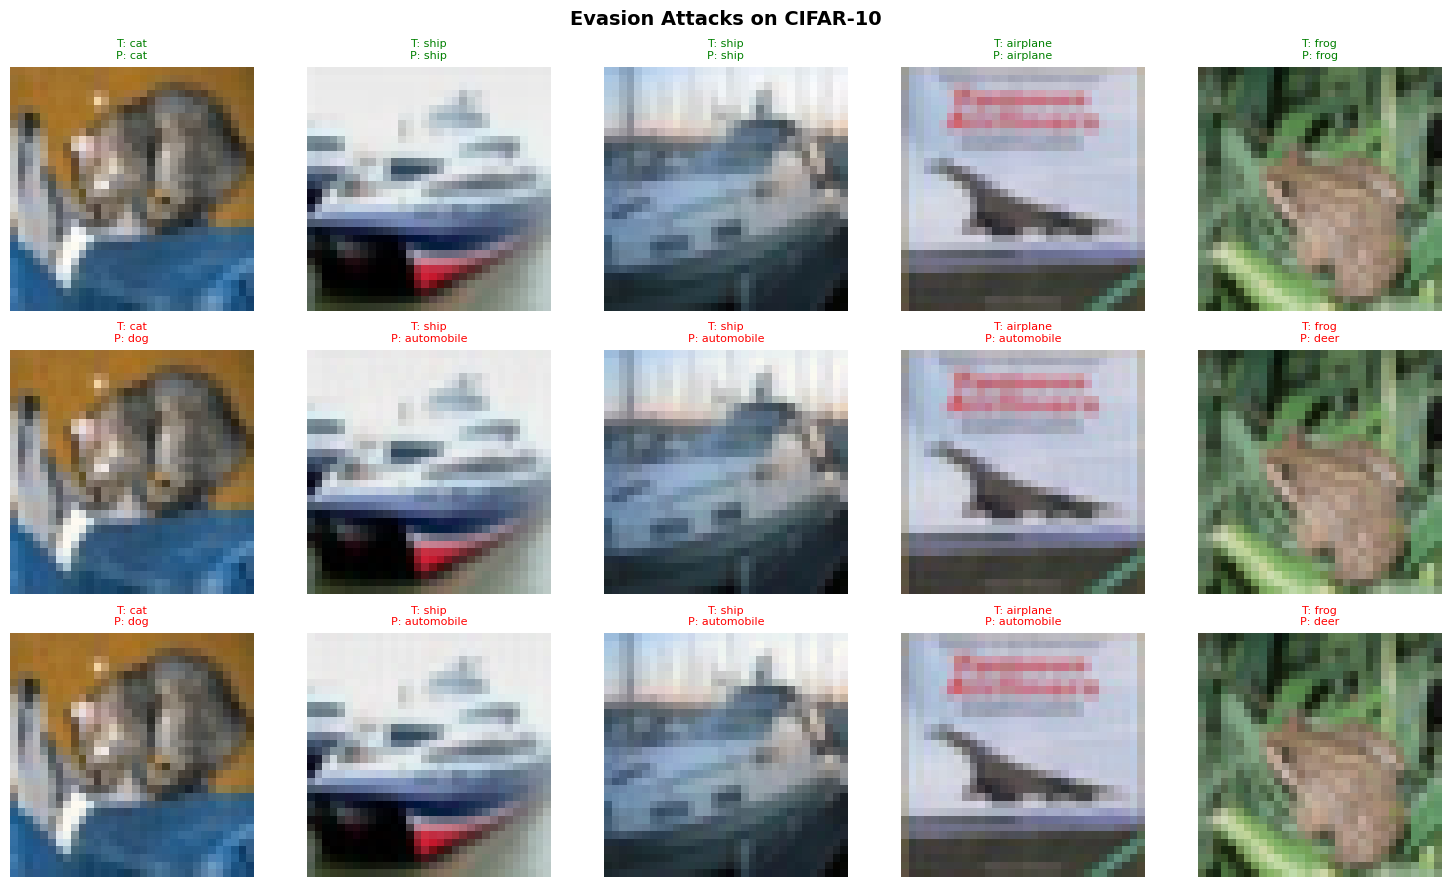

Saved: attack_visualisation.png


In [4]:
# ── Main ──────────────────────────────────────────────────────────────────────
def main():
    # Hyper-parameters
    EPOCHS    = 10
    LR        = 1e-3
    EPSILON   = 0.03   # L∞ threat-model radius
    ALPHA     = 0.007  # PGD step size  (≈ epsilon / 4)
    PGD_STEPS = 20     # PGD iterations

    # ── Data & model ──────────────────────────────────────────────────────────
    train_loader, test_loader = get_loaders()
    model     = SimpleCNN().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()

    # ── Train ─────────────────────────────────────────────────────────────────
    print("\n=== Training ===")
    train(model, train_loader, optimizer, criterion, epochs=EPOCHS)

    clean_acc = evaluate(model, test_loader)
    print(f"\nClean test accuracy: {clean_acc:.1f}%")

    # ── Evaluate under attack ──────────────────────────────────────────────────
    print("\n=== Evaluating under FGSM ===")
    fgsm_acc = evaluate_under_attack(
        model, test_loader,
        attack_fn=fgsm_attack,
        attack_kwargs={"epsilon": EPSILON},
    )
    print(f"FGSM accuracy (ε={EPSILON}): {fgsm_acc:.1f}%")

    print("\n=== Evaluating under PGD ===")
    pgd_acc = evaluate_under_attack(
        model, test_loader,
        attack_fn=pgd_attack,
        attack_kwargs={"epsilon": EPSILON, "alpha": ALPHA,
                       "num_steps": PGD_STEPS},
    )
    print(f"PGD accuracy  (ε={EPSILON}, steps={PGD_STEPS}): {pgd_acc:.1f}%")

    # ── Summary ───────────────────────────────────────────────────────────────
    print("\n" + "="*45)
    print(f"{'Attack':<25} {'Accuracy':>10}")
    print("-"*45)
    print(f"{'Clean (no attack)':<25} {clean_acc:>9.1f}%")
    print(f"{'FGSM':<25} {fgsm_acc:>9.1f}%")
    print(f"{'PGD':<25} {pgd_acc:>9.1f}%")
    print("="*45)

    # ── Visualise ─────────────────────────────────────────────────────────────
    sample_images, sample_labels = next(iter(test_loader))
    visualise_attacks(model, sample_images, sample_labels,
                      EPSILON, ALPHA, PGD_STEPS, n=5)


if __name__ == "__main__":
    main()